# 📊 Exploratory Data Analysis (EDA)
### Bayesian Time-Series Forecasting System

**Dataset:** NIFTY50 / S&P500 / RELIANCE  
**Goal:** Understand statistical properties before modeling  

---

### Key Questions:
- Is the series stationary?
- Are returns normally distributed?
- Do we observe volatility clustering?
- What features correlate with target?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("dark_background")

In [2]:
df = pd.read_csv("../data/processed/nifty50_features.csv", parse_dates=["Date"], index_col="Date")
df.head()

,Open,High,Low,Close,Volume,return_1d,log_return_1d,log_return_cum,dow_sin,dow_cos,...,roll63d_close_ma,volatility_ann,rsi_14,bb_upper,bb_lower,bb_width,bb_pct,atr_14,ma_cross_50_200,target_5d
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-19,6114.450195,6127.049805,6008.149902,6027.299805,0,-0.008007,-0.008039,0.141467,0.951057,0.309017,...,5709.165884,0.154485,52.371535,6236.751582,5935.048369,0.049574,0.305769,103.950056,0.076026,0.009075
2010-10-20,6002.950195,6038.100098,5966.750000,5982.100098,0,-0.007499,-0.007527,0.133940,0.587785,-0.809017,...,5717.739692,0.155940,46.874795,6237.532822,5933.377138,0.049981,0.160191,102.985770,0.077717,0.005107
2010-10-21,6008.899902,6113.500000,5984.899902,6101.500000,0,0.019960,0.019763,0.153703,-0.587785,-0.809017,...,5728.095246,0.170106,47.284522,6232.668434,5952.436546,0.045996,0.531929,103.575056,0.077753,-0.018651
2010-10-22,6113.399902,6121.100098,6041.350098,6066.049805,0,-0.005810,-0.005827,0.147876,-0.951057,0.309017,...,5738.372225,0.170373,44.095320,6231.305750,5958.574231,0.044747,0.394071,103.650042,0.079703,-0.007971
2010-10-25,6101.250000,6151.299805,6094.600098,6105.799805,0,0.006553,0.006531,0.154407,0.000000,1.000000,...,5749.089681,0.168568,47.552023,6231.971201,5964.923770,0.043789,0.527532,104.717878,0.080635,0.001924


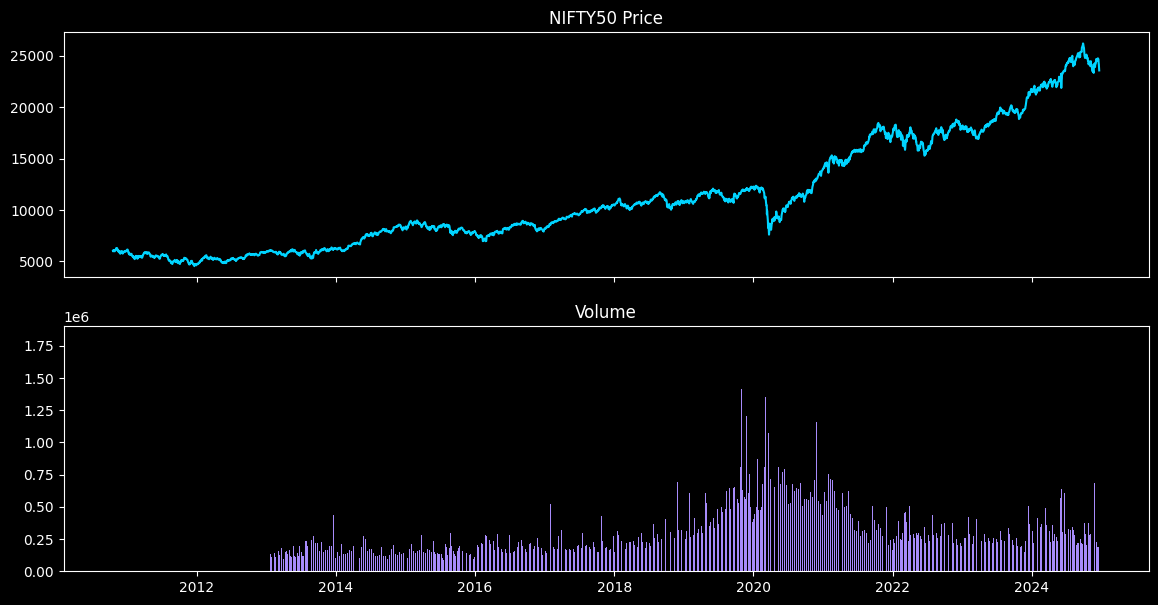

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,7), sharex=True)

ax1.plot(df.index, df["Close"], color="#00d4ff")
ax1.set_title("NIFTY50 Price")

ax2.bar(df.index, df["Volume"], color="#a78bfa")
ax2.set_title("Volume")

plt.show()

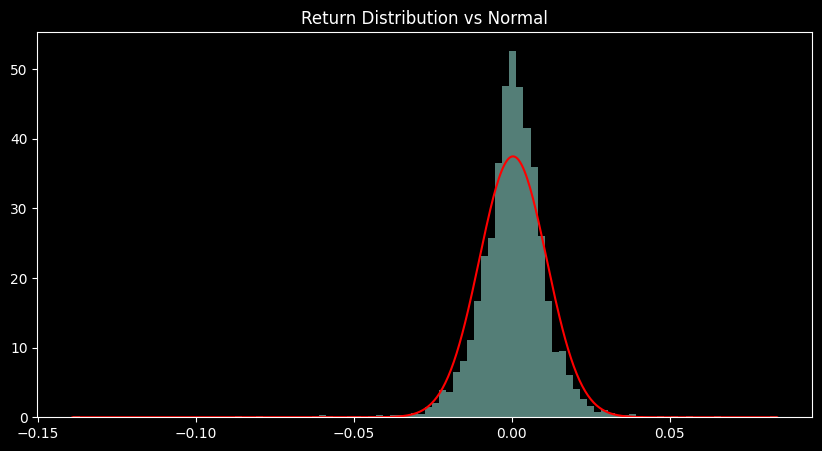

In [4]:
returns = df["log_return_1d"].dropna()

plt.figure(figsize=(10,5))
plt.hist(returns, bins=100, density=True, alpha=0.6)

x = np.linspace(returns.min(), returns.max(), 500)
plt.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), color="red")

plt.title("Return Distribution vs Normal")
plt.show()

In [5]:
print("Mean:", returns.mean())
print("Volatility:", returns.std())
print("Skewness:", returns.skew())
print("Kurtosis:", returns.kurt())

_, p_jb = stats.jarque_bera(returns)
print("Jarque-Bera p-value:", p_jb)

Mean: 0.0003904240114229932
Volatility: 0.010646880770052313
Skewness: -0.9604537891307937
Kurtosis: 14.13283845560704
Jarque-Bera p-value: 0.0


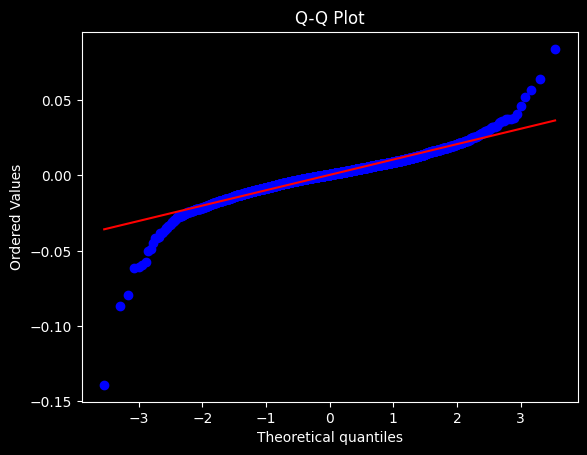

In [6]:
stats.probplot(returns, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

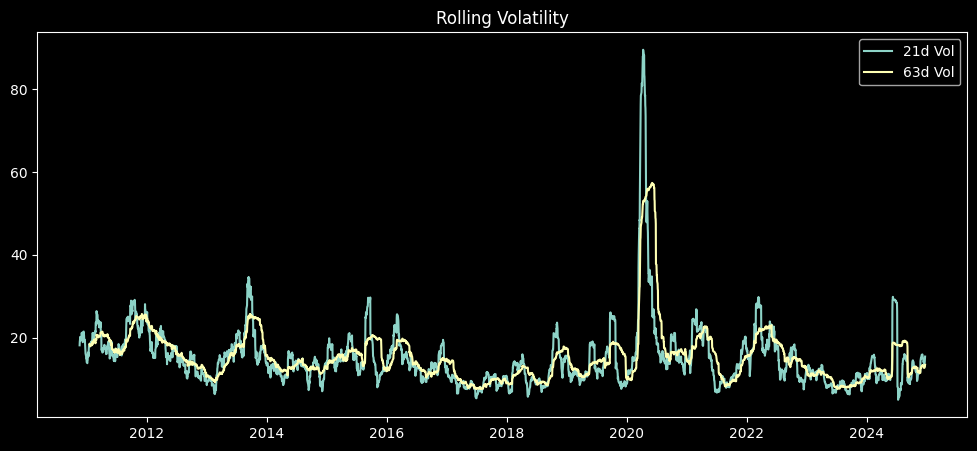

In [7]:
vol_21 = returns.rolling(21).std() * np.sqrt(252) * 100
vol_63 = returns.rolling(63).std() * np.sqrt(252) * 100

plt.figure(figsize=(12,5))
plt.plot(vol_21, label="21d Vol")
plt.plot(vol_63, label="63d Vol")
plt.legend()
plt.title("Rolling Volatility")
plt.show()

In [8]:
def check_stationarity(series):
    adf_stat, adf_p, *_ = adfuller(series.dropna())
    print(f"ADF p-value: {adf_p}")

    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c")
    print(f"KPSS p-value: {kpss_p}")

print("Close Price:")
check_stationarity(df["Close"])

print("\nLog Returns:")
check_stationarity(df["log_return_1d"])

Close Price:
ADF p-value: 0.9941199373396166
KPSS p-value: 0.01

Log Returns:
ADF p-value: 1.6619265483357114e-29
KPSS p-value: 0.1


C:\Users\dines\AppData\Local\Temp\ipykernel_20252\1657341606.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c")
C:\Users\dines\AppData\Local\Temp\ipykernel_20252\1657341606.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c")


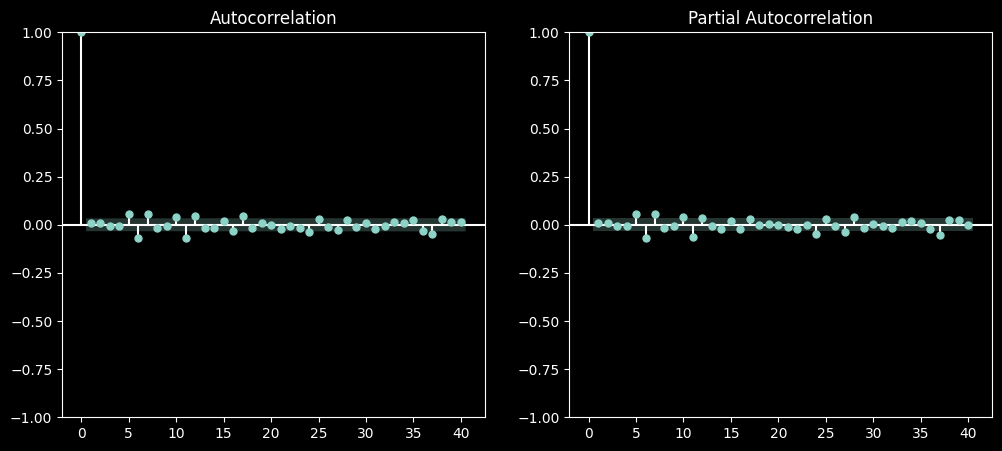

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_acf(returns, lags=40, ax=axes[0])
plot_pacf(returns, lags=40, ax=axes[1])

plt.show()

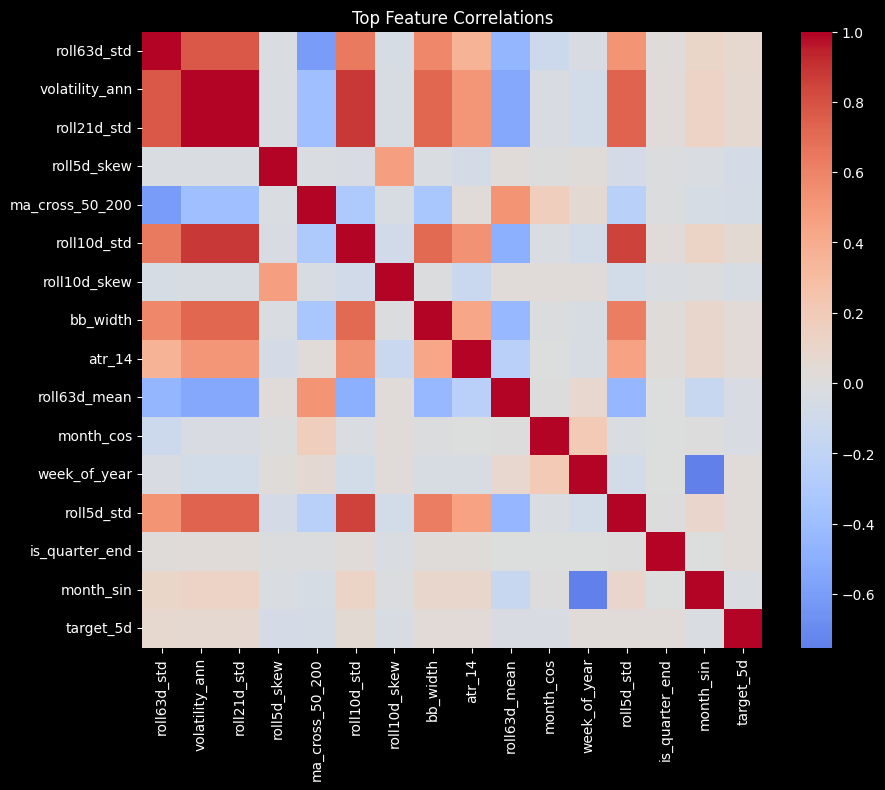

In [10]:
target = "target_5d"

feature_cols = [c for c in df.columns if c not in ["Open","High","Low","Close","Volume", target]]

corrs = df[feature_cols].corrwith(df[target]).abs().sort_values(ascending=False)
top_features = corrs.head(15).index.tolist() + [target]

corr_matrix = df[top_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Top Feature Correlations")
plt.show()

## 🔍 Key Insights

- ❌ Prices are non-stationary (ADF, KPSS)
- ✅ Log returns are stationary → suitable for modeling
- ⚠️ Returns show **fat tails (high kurtosis)** → not normal
- 📉 Negative skew → downside risk (crashes)
- 📊 Volatility clustering observed → supports GARCH/Bayesian models
- 🔗 Certain lag/rolling features show predictive power

---

### 💡 Interview Talking Point

> “I validated stationarity using ADF and KPSS tests and confirmed that log returns are stationary while prices are not. I also observed fat tails and volatility clustering, which indicates that Gaussian assumptions are violated in financial time series.”